# 基于Reuters数据集的新闻文本46分类实验

## 毕业设计实验代码

### 实验概述
本实验基于Reuters-21578新闻数据集，使用多种自然语言处理方法进行新闻主题的46分类任务，
系统性地对比传统机器学习方法与深度学习方法在多分类文本任务上的表现。

### 与二分类任务的区别
| 对比维度 | 二分类（IMDB） | 多分类（Reuters） |
|----------|----------------|-------------------|
| 类别数 | 2（正面/负面） | 46个新闻主题 |
| 损失函数 | BCELoss | CrossEntropyLoss |
| 输出层 | Sigmoid（1个输出） | Softmax（46个输出） |
| 评价指标 | 二分类F1 | macro/weighted F1 |
| 数据特点 | 类别均衡 | 类别严重不均衡 |

### 实验模型
| 序号 | 模型 | 类别 |
|------|------|------|
| 1 | Naive Bayes + TF-IDF | 传统机器学习 |
| 2 | TextCNN | 深度学习 |
| 3 | BiLSTM | 深度学习 |
| 4 | Transformer Encoder | 深度学习 |

### 数据集
- Reuters-21578 新闻分类数据集
- 共11,228条新闻，46个类别
- 数据已预处理为词索引序列格式（reuters.npz）

## 第1部分：环境配置与依赖导入

In [1]:
# ============================================================================
# 第1部分：导入所有依赖库
# ============================================================================

import os
import re
import math
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- 设置matplotlib支持中文显示 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --- Scikit-learn ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

warnings.filterwarnings('ignore')
print("所有依赖库导入成功！")

所有依赖库导入成功！


## 第2部分：全局超参数配置

In [2]:
# ============================================================================
# 第2部分：全局超参数配置
# ============================================================================

NUM_CLASSES    = 46      # Reuters数据集共46个新闻类别
MAX_SEQ_LEN    = 200     # 输入序列最大长度
EMBEDDING_DIM  = 128     # 词向量维度
BATCH_SIZE     = 64      # 批大小
EPOCHS         = 10      # 训练轮数（多分类任务通常需要更多轮次）
LEARNING_RATE  = 1e-3    # 学习率
NUM_HEADS      = 4       # Transformer多头注意力的头数
NUM_LAYERS     = 2       # Transformer编码器层数
FF_DIM         = 256     # Transformer前馈网络隐藏层维度

# --- 自动检测计算设备 ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'计算设备: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU型号: {torch.cuda.get_device_name(0)}')

计算设备: cuda
GPU型号: NVIDIA GeForce RTX 4060 Laptop GPU


## 第3部分：数据加载与预处理

Reuters数据集已预处理为词索引序列格式（reuters.npz），每条新闻是一个整数列表，每个整数代表一个词的索引。

需要完成的工作：
1. 加载npz数据，划分训练集/测试集
2. 构建反向词表（索引→词），将索引序列还原为文本（供TF-IDF使用）
3. 填充/截断序列到固定长度（供深度学习模型使用）

In [3]:
# ============================================================================
# 第3部分：数据加载与预处理
# ============================================================================

# --- 3.1 加载Reuters数据集 ---
# reuters.npz 包含:
#   x: 每条新闻的词索引序列（list of int），长度不等
#   y: 每条新闻的类别标签（0~45）
print("加载Reuters数据集...")
npz_data = np.load('../reuters.npz', allow_pickle=True)
all_x = npz_data['x']  # shape=(11228,), 每个元素是一个int列表
all_y = npz_data['y']  # shape=(11228,), int64

print(f"数据集总量: {len(all_x)} 条新闻")
print(f"类别数: {len(np.unique(all_y))} 类")
print(f"标签范围: {all_y.min()} ~ {all_y.max()}")

# --- 3.2 划分训练集/测试集 ---
# Reuters标准划分: 前8982条为训练集，后2246条为测试集
TRAIN_SIZE = 8982

x_train_raw = all_x[:TRAIN_SIZE]
y_train     = all_y[:TRAIN_SIZE]
x_test_raw  = all_x[TRAIN_SIZE:]
y_test      = all_y[TRAIN_SIZE:]

print(f"\n训练集: {len(x_train_raw)} 条")
print(f"测试集: {len(x_test_raw)} 条")

# --- 3.3 统计序列长度 ---
train_lengths = [len(seq) for seq in x_train_raw]
print(f"\n训练集序列长度统计:")
print(f"  均值: {np.mean(train_lengths):.0f}")
print(f"  中位数: {np.median(train_lengths):.0f}")
print(f"  最大: {np.max(train_lengths)}")
print(f"  最小: {np.min(train_lengths)}")

# --- 3.4 构建词表 ---
# 统计数据中出现的所有词索引，找到最大索引作为词表大小
all_word_indices = set()
for seq in all_x:
    all_word_indices.update(seq)
VOCAB_SIZE = max(all_word_indices) + 1  # 索引从0开始，所以+1
PAD_IDX = 0  # 用0作为填充索引

print(f"\n词表大小（最大索引+1）: {VOCAB_SIZE}")

# --- 3.5 将索引序列还原为"文本"（供TF-IDF使用）---
# 由于reuters.npz只有索引没有原始词，我们将索引直接当作"词"拼接成字符串
# TF-IDF会把每个索引数字当作一个独立的token来处理
def indices_to_text(seq):
    """将词索引序列转为空格分隔的字符串（用于TF-IDF）"""
    return ' '.join(str(idx) for idx in seq)

train_texts = [indices_to_text(seq) for seq in x_train_raw]
test_texts  = [indices_to_text(seq) for seq in x_test_raw]

print(f"\n文本化示例（前50字符）: {train_texts[0][:50]}...")

# --- 3.6 序列填充/截断（供深度学习模型使用）---
def pad_sequence(seq, max_len, pad_value=0):
    """将序列填充或截断到固定长度"""
    if len(seq) >= max_len:
        return seq[:max_len]
    else:
        return seq + [pad_value] * (max_len - len(seq))

x_train_padded = np.array([pad_sequence(list(seq), MAX_SEQ_LEN) for seq in x_train_raw])
x_test_padded  = np.array([pad_sequence(list(seq), MAX_SEQ_LEN) for seq in x_test_raw])

print(f"\n填充后训练集: {x_train_padded.shape}")
print(f"填充后测试集: {x_test_padded.shape}")

# --- 3.7 创建PyTorch DataLoader ---
train_dataset = data.TensorDataset(
    torch.tensor(x_train_padded, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = data.TensorDataset(
    torch.tensor(x_test_padded, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long)
)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoader: 训练{len(train_loader)}个batch, 测试{len(test_loader)}个batch")

加载Reuters数据集...
数据集总量: 11228 条新闻
类别数: 46 类
标签范围: 0 ~ 45

训练集: 8982 条
测试集: 2246 条

训练集序列长度统计:
  均值: 144
  中位数: 94
  最大: 2375
  最小: 1

词表大小（最大索引+1）: 30980

文本化示例（前50字符）: 6216 667 1907 1 118 4 1 6680 662 2342 25470 1 1716...

填充后训练集: (8982, 200)
填充后测试集: (2246, 200)

DataLoader: 训练141个batch, 测试36个batch


## 第4部分：探索性数据分析（EDA）

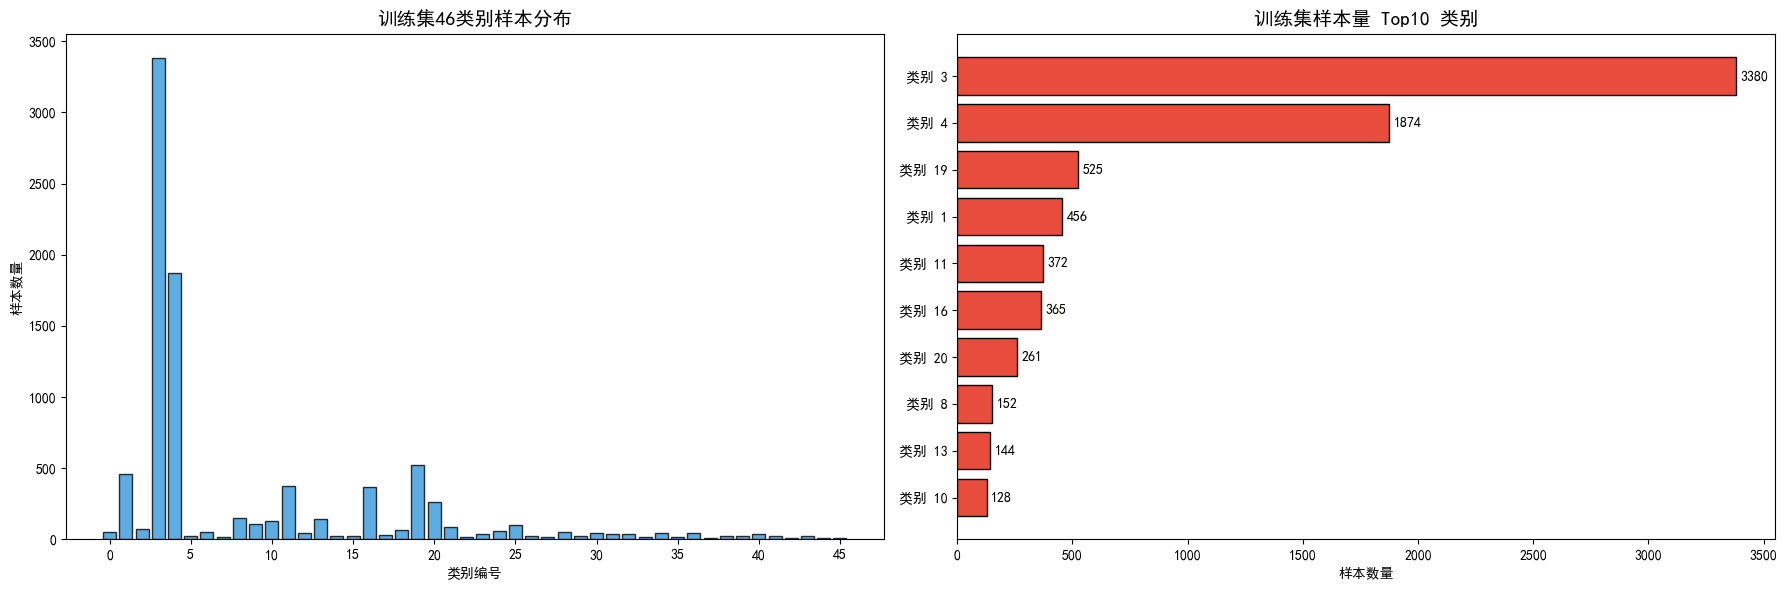

类别样本量统计:
  最多: 类别3 (3380条)
  最少: 类别42 (8条)
  均值: 195条
  样本量<10的类别数: 2
  样本量<50的类别数: 28


In [4]:
# ============================================================================
# 第4部分：探索性数据分析（EDA）
# ============================================================================

# --- 4.1 类别分布分析 ---
# Reuters数据集的一个重要特点是类别严重不均衡
# 某些类别（如"earn"、"acq"）样本量很大，而很多类别只有几条样本
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 训练集类别分布
train_label_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(range(NUM_CLASSES), [train_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
            color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('训练集46类别样本分布', fontsize=14)
axes[0].set_xlabel('类别编号')
axes[0].set_ylabel('样本数量')
axes[0].set_xticks(range(0, NUM_CLASSES, 5))

# Top10类别
top10 = pd.Series(y_train).value_counts().head(10)
axes[1].barh(range(10), top10.values[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f'类别 {c}' for c in top10.index[::-1]])
axes[1].set_title('训练集样本量 Top10 类别', fontsize=14)
axes[1].set_xlabel('样本数量')
for i, v in enumerate(top10.values[::-1]):
    axes[1].text(v + 20, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印统计信息
print(f"类别样本量统计:")
print(f"  最多: 类别{train_label_counts.idxmax()} ({train_label_counts.max()}条)")
print(f"  最少: 类别{train_label_counts.idxmin()} ({train_label_counts.min()}条)")
print(f"  均值: {train_label_counts.mean():.0f}条")
print(f"  样本量<10的类别数: {(train_label_counts < 10).sum()}")
print(f"  样本量<50的类别数: {(train_label_counts < 50).sum()}")

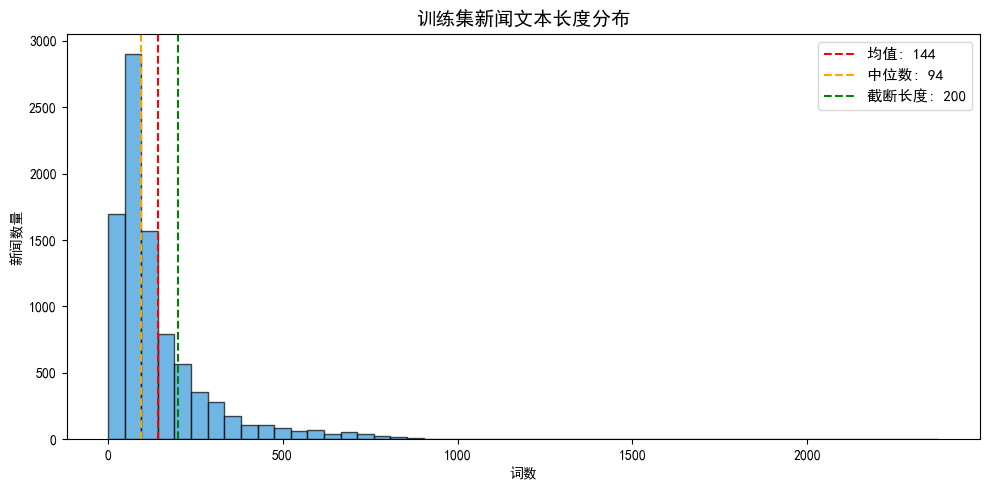

超过200词的新闻占比: 20.8%


In [5]:
# --- 4.2 文本长度分布 ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_lengths, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(train_lengths), color='red', linestyle='--',
           label=f'均值: {np.mean(train_lengths):.0f}')
ax.axvline(x=np.median(train_lengths), color='orange', linestyle='--',
           label=f'中位数: {np.median(train_lengths):.0f}')
ax.axvline(x=MAX_SEQ_LEN, color='green', linestyle='--',
           label=f'截断长度: {MAX_SEQ_LEN}')
ax.set_title('训练集新闻文本长度分布', fontsize=14)
ax.set_xlabel('词数')
ax.set_ylabel('新闻数量')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150)
plt.show()

print(f"超过{MAX_SEQ_LEN}词的新闻占比: "
      f"{sum(1 for l in train_lengths if l > MAX_SEQ_LEN) / len(train_lengths) * 100:.1f}%")

## 第5部分：模型1 - 朴素贝叶斯 (Naive Bayes + TF-IDF)

多分类朴素贝叶斯与二分类的区别：
- 二分类输出1个概率值，多分类输出46个类别的概率分布
- 评价指标使用 `macro` 平均（对每个类别平等对待）和 `weighted` 平均（按样本量加权）

训练模型1：朴素贝叶斯 (Naive Bayes)
TF-IDF特征维度: (8982, 10000)

--- 朴素贝叶斯评估结果 ---
Accuracy:        0.7640
Precision (加权): 0.7432
Recall (加权):    0.7640
F1 (macro):      0.4010
F1 (weighted):   0.7320


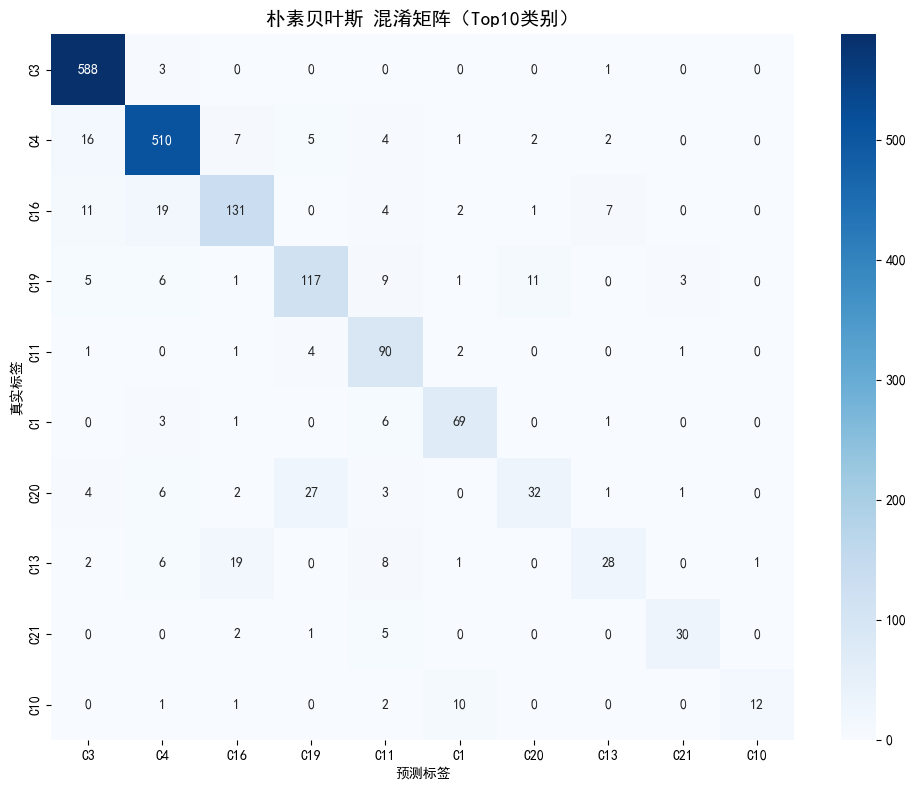

In [6]:
# ============================================================================
# 第5部分：朴素贝叶斯 (Naive Bayes + TF-IDF)
# ============================================================================
print("=" * 50)
print("训练模型1：朴素贝叶斯 (Naive Bayes)")
print("=" * 50)

# --- 5.1 TF-IDF特征提取 ---
# 将词索引字符串转为TF-IDF特征向量
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),   # unigram + bigram
    sublinear_tf=True     # 对数TF平滑
)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)
print(f"TF-IDF特征维度: {X_train_tfidf.shape}")

# --- 5.2 训练朴素贝叶斯 ---
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# --- 5.3 预测与评估 ---
y_pred_nb = nb_model.predict(X_test_tfidf)

# 多分类评价指标
# macro: 对每个类别的指标取算术平均（不考虑类别样本量，对小类别更公平）
# weighted: 按每个类别的样本量加权平均（反映整体表现）
nb_acc       = accuracy_score(y_test, y_pred_nb)
nb_f1_macro  = f1_score(y_test, y_pred_nb, average='macro', zero_division=0)
nb_f1_weight = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_prec      = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_recall    = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"\n--- 朴素贝叶斯评估结果 ---")
print(f"Accuracy:        {nb_acc:.4f}")
print(f"Precision (加权): {nb_prec:.4f}")
print(f"Recall (加权):    {nb_recall:.4f}")
print(f"F1 (macro):      {nb_f1_macro:.4f}")
print(f"F1 (weighted):   {nb_f1_weight:.4f}")

# --- 5.4 混淆矩阵可视化（取Top10类别）---
# 46类的完整混淆矩阵太大，只展示样本量最多的10个类别
top10_classes = pd.Series(y_test).value_counts().head(10).index.tolist()
mask_test  = np.isin(y_test, top10_classes)
mask_pred  = np.isin(y_pred_nb, top10_classes)
mask = mask_test & mask_pred

cm_nb_top10 = confusion_matrix(
    y_test[mask], y_pred_nb[mask], labels=top10_classes
)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb_top10, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'C{c}' for c in top10_classes],
            yticklabels=[f'C{c}' for c in top10_classes])
plt.title('朴素贝叶斯 混淆矩阵（Top10类别）', fontsize=14)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()

## 第6部分：通用训练与评估函数（多分类版本）

与二分类的关键区别：
- 损失函数：`CrossEntropyLoss`（内含Softmax，输出46个类别的概率）
- 预测方式：`argmax` 取概率最大的类别
- 评价指标：使用 `macro` 和 `weighted` 两种F1平均方式

In [7]:
# ============================================================================
# 第6部分：通用训练与评估函数（多分类版本）
# ============================================================================

def train_epoch_mc(model, loader, criterion, optimizer):
    """
    多分类模型训练一个epoch
    
    与二分类的区别:
        - 标签为long类型（类别索引），不需要转float
        - CrossEntropyLoss内部包含Softmax，模型输出原始logits即可
    """
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)              # (batch, num_classes) 原始分数
        loss = criterion(logits, yb)    # CrossEntropyLoss自动做Softmax
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_model_mc(model, loader):
    """
    多分类模型评估
    
    返回: acc, f1_macro, f1_weighted, all_preds, all_labels
    """
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()  # 取概率最大的类别
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    acc       = accuracy_score(all_labels, all_preds)
    f1_macro  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weight = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return acc, f1_macro, f1_weight, all_preds, all_labels


def train_and_evaluate_mc(model, model_name, criterion, optimizer, epochs):
    """
    完整训练+评估流程（多分类版本），记录训练历史
    """
    history = {'train_loss': [], 'test_acc': [], 'test_f1_macro': [], 'test_f1_weight': []}
    
    print(f"\n{'='*50}")
    print(f"开始训练 {model_name}")
    print(f"{'='*50}")
    
    for epoch in range(epochs):
        t0 = time.time()
        train_loss = train_epoch_mc(model, train_loader, criterion, optimizer)
        acc, f1m, f1w, _, _ = eval_model_mc(model, test_loader)
        elapsed = time.time() - t0
        
        history['train_loss'].append(train_loss)
        history['test_acc'].append(acc)
        history['test_f1_macro'].append(f1m)
        history['test_f1_weight'].append(f1w)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - "
              f"Acc: {acc:.4f} - F1(macro): {f1m:.4f} - F1(weighted): {f1w:.4f} - "
              f"耗时: {elapsed:.1f}s")
    
    return history


def plot_training_and_cm(history, model_name, preds, labels, color, cmap):
    """绘制训练曲线和混淆矩阵"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ep = range(1, len(history['train_loss']) + 1)
    
    # 损失曲线
    axes[0].plot(ep, history['train_loss'], f'{color}-o', linewidth=2, markersize=5)
    axes[0].set_title(f'{model_name} 训练损失', fontsize=14)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True, alpha=0.3)
    
    # 准确率曲线
    axes[1].plot(ep, history['test_acc'], 'g-o', linewidth=2, markersize=5)
    axes[1].set_title(f'{model_name} 测试准确率', fontsize=14)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].grid(True, alpha=0.3)
    
    # 混淆矩阵（Top10类别）
    mask = np.isin(labels, top10_classes) & np.isin(preds, top10_classes)
    cm = confusion_matrix(labels[mask], preds[mask], labels=top10_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[2],
                xticklabels=[f'C{c}' for c in top10_classes],
                yticklabels=[f'C{c}' for c in top10_classes])
    axes[2].set_title(f'{model_name} 混淆矩阵(Top10)', fontsize=14)
    axes[2].set_xlabel('预测'); axes[2].set_ylabel('真实')
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_results.png', dpi=150, bbox_inches='tight')
    plt.show()


print("通用训练/评估函数（多分类版本）定义完成。")

通用训练/评估函数（多分类版本）定义完成。


## 第7部分：模型2 - TextCNN（多分类版本）

与二分类TextCNN的区别：输出层从 `Linear(n, 1) + Sigmoid` 变为 `Linear(n, 46)`（无需Sigmoid，CrossEntropyLoss内含Softmax）

TextCNN 参数量: 4,072,814

开始训练 TextCNN
Epoch 1/10 - Loss: 2.0647 - Acc: 0.6220 - F1(macro): 0.0850 - F1(weighted): 0.5225 - 耗时: 1.8s
Epoch 2/10 - Loss: 1.4689 - Acc: 0.7021 - F1(macro): 0.2139 - F1(weighted): 0.6386 - 耗时: 0.7s
Epoch 3/10 - Loss: 1.2388 - Acc: 0.7289 - F1(macro): 0.2553 - F1(weighted): 0.6704 - 耗时: 0.8s
Epoch 4/10 - Loss: 1.1006 - Acc: 0.7320 - F1(macro): 0.3048 - F1(weighted): 0.6773 - 耗时: 0.8s
Epoch 5/10 - Loss: 0.9785 - Acc: 0.7498 - F1(macro): 0.3365 - F1(weighted): 0.7052 - 耗时: 0.7s
Epoch 6/10 - Loss: 0.8837 - Acc: 0.7582 - F1(macro): 0.3748 - F1(weighted): 0.7218 - 耗时: 0.8s
Epoch 7/10 - Loss: 0.8085 - Acc: 0.7565 - F1(macro): 0.3980 - F1(weighted): 0.7208 - 耗时: 0.8s
Epoch 8/10 - Loss: 0.7201 - Acc: 0.7516 - F1(macro): 0.4187 - F1(weighted): 0.7118 - 耗时: 0.7s
Epoch 9/10 - Loss: 0.6559 - Acc: 0.7685 - F1(macro): 0.4411 - F1(weighted): 0.7355 - 耗时: 0.7s
Epoch 10/10 - Loss: 0.5933 - Acc: 0.7725 - F1(macro): 0.4954 - F1(weighted): 0.7439 - 耗时: 0.7s

--- TextCNN 最终结果 ---


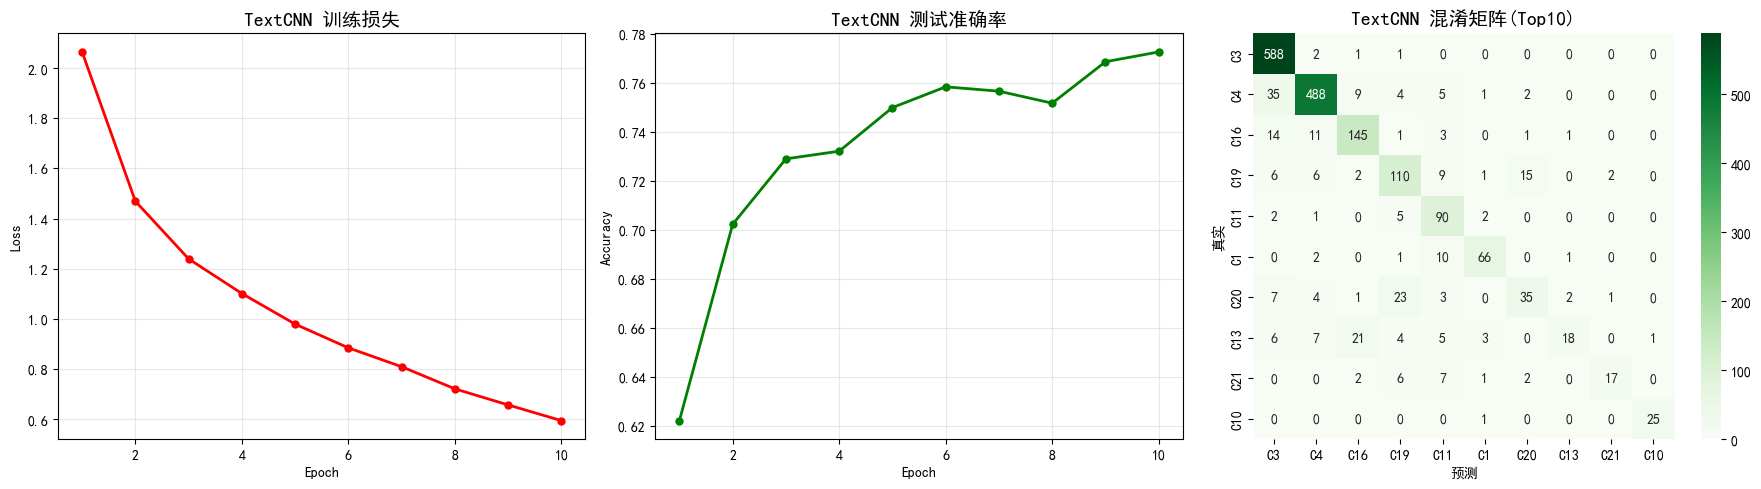

In [8]:
# ============================================================================
# 第7部分：TextCNN 多分类模型
# ============================================================================

class TextCNN_MC(nn.Module):
    """
    TextCNN 多分类版本
    
    与二分类版本的区别:
        - 输出层: Linear(num_filters*3, NUM_CLASSES) 输出46个类别的logits
        - 不需要Sigmoid，因为CrossEntropyLoss内部包含Softmax
    """
    def __init__(self, vocab_size, embed_dim, num_filters=64,
                 filter_sizes=[3, 4, 5], num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        
        # 多尺度卷积核: 分别捕捉3-gram, 4-gram, 5-gram特征
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        
        # 输出46个类别的原始分数（logits）
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.embedding(x)           # (batch, seq, embed)
        x = x.permute(0, 2, 1)          # (batch, embed, seq) 适配Conv1d
        
        # 多尺度卷积 + ReLU + 全局最大池化
        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            c = torch.max(c, dim=2)[0]  # 全局最大池化
            conv_outs.append(c)
        
        x = torch.cat(conv_outs, dim=1) # 拼接所有卷积核输出
        x = self.dropout(x)
        return self.fc(x)               # (batch, NUM_CLASSES) 输出logits


# --- 初始化并训练 ---
model_cnn = TextCNN_MC(VOCAB_SIZE, EMBEDDING_DIM).to(DEVICE)
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失（内含Softmax）
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)

print(f"TextCNN 参数量: {sum(p.numel() for p in model_cnn.parameters()):,}")

history_cnn = train_and_evaluate_mc(model_cnn, "TextCNN", criterion, optimizer_cnn, EPOCHS)

# 最终评估
cnn_acc, cnn_f1m, cnn_f1w, cnn_preds, cnn_labels = eval_model_mc(model_cnn, test_loader)
cnn_prec = precision_score(cnn_labels, cnn_preds, average='weighted', zero_division=0)
cnn_rec  = recall_score(cnn_labels, cnn_preds, average='weighted', zero_division=0)

print(f"\n--- TextCNN 最终结果 ---")
print(f"Accuracy: {cnn_acc:.4f}, F1(macro): {cnn_f1m:.4f}, F1(weighted): {cnn_f1w:.4f}")

plot_training_and_cm(history_cnn, "TextCNN", cnn_preds, cnn_labels, 'r', 'Greens')

## 第8部分：模型3 - BiLSTM（多分类版本）

BiLSTM 参数量: 4,070,702

开始训练 BiLSTM
Epoch 1/10 - Loss: 2.6961 - Acc: 0.2645 - F1(macro): 0.0097 - F1(weighted): 0.1120 - 耗时: 0.9s
Epoch 2/10 - Loss: 2.3555 - Acc: 0.2747 - F1(macro): 0.0116 - F1(weighted): 0.1332 - 耗时: 0.9s
Epoch 3/10 - Loss: 2.3184 - Acc: 0.2752 - F1(macro): 0.0137 - F1(weighted): 0.1353 - 耗时: 0.8s
Epoch 4/10 - Loss: 2.3056 - Acc: 0.2778 - F1(macro): 0.0146 - F1(weighted): 0.1402 - 耗时: 0.7s
Epoch 5/10 - Loss: 2.2450 - Acc: 0.2961 - F1(macro): 0.0220 - F1(weighted): 0.1665 - 耗时: 0.7s
Epoch 6/10 - Loss: 2.2336 - Acc: 0.2881 - F1(macro): 0.0177 - F1(weighted): 0.1596 - 耗时: 0.7s
Epoch 7/10 - Loss: 2.2295 - Acc: 0.2836 - F1(macro): 0.0163 - F1(weighted): 0.1514 - 耗时: 0.7s
Epoch 8/10 - Loss: 2.2102 - Acc: 0.2939 - F1(macro): 0.0221 - F1(weighted): 0.1711 - 耗时: 0.7s
Epoch 9/10 - Loss: 1.9740 - Acc: 0.3005 - F1(macro): 0.0263 - F1(weighted): 0.1776 - 耗时: 0.7s
Epoch 10/10 - Loss: 1.8465 - Acc: 0.3571 - F1(macro): 0.0374 - F1(weighted): 0.2799 - 耗时: 0.7s

--- BiLSTM 最终结果 ---
Acc

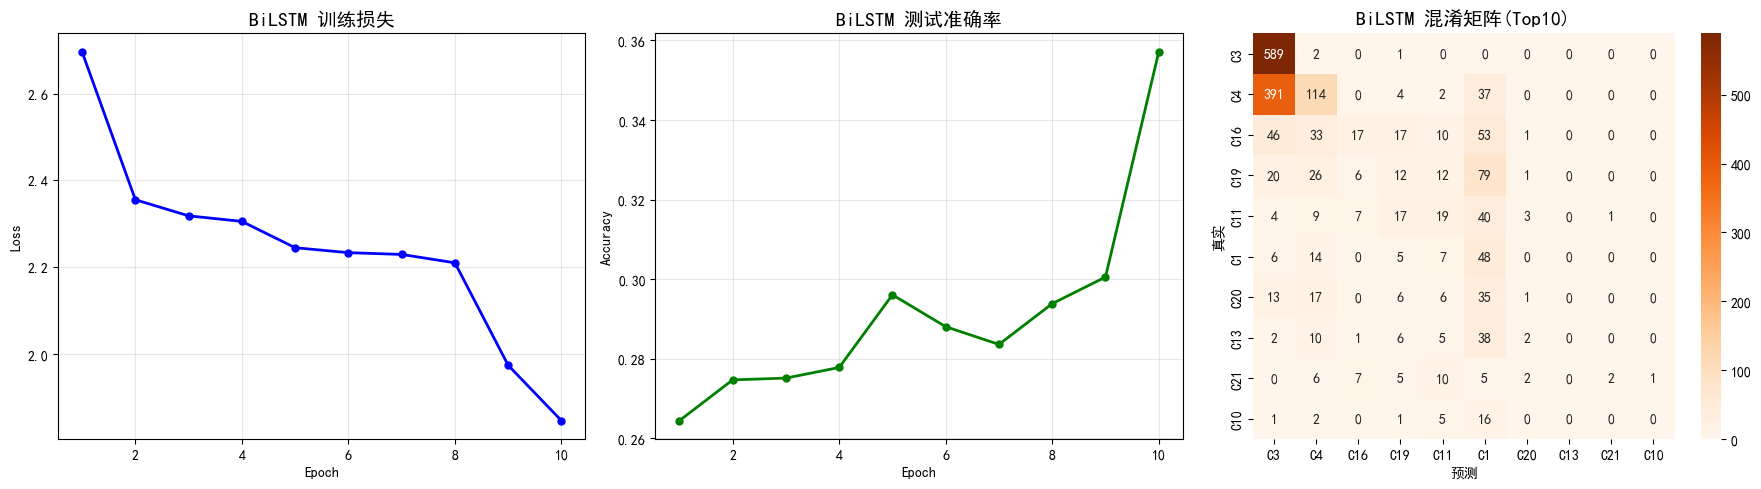

In [9]:
# ============================================================================
# 第8部分：BiLSTM 多分类模型
# ============================================================================

class BiLSTM_MC(nn.Module):
    """
    BiLSTM 多分类版本
    
    与二分类版本的区别:
        - 输出层: Linear(hidden*2, NUM_CLASSES)
        - 不需要Sigmoid
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim=64, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True  # 双向LSTM
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # 双向所以*2
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        embed = self.embedding(x)                # (batch, seq, embed)
        lstm_out, _ = self.lstm(embed)           # (batch, seq, hidden*2)
        out = lstm_out[:, -1, :]                 # 取最后时间步 (batch, hidden*2)
        out = self.dropout(out)
        return self.fc(out)                      # (batch, NUM_CLASSES)


# --- 初始化并训练 ---
model_lstm = BiLSTM_MC(VOCAB_SIZE, EMBEDDING_DIM).to(DEVICE)
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

print(f"BiLSTM 参数量: {sum(p.numel() for p in model_lstm.parameters()):,}")

history_lstm = train_and_evaluate_mc(model_lstm, "BiLSTM", criterion_lstm, optimizer_lstm, EPOCHS)

# 最终评估
lstm_acc, lstm_f1m, lstm_f1w, lstm_preds, lstm_labels = eval_model_mc(model_lstm, test_loader)
lstm_prec = precision_score(lstm_labels, lstm_preds, average='weighted', zero_division=0)
lstm_rec  = recall_score(lstm_labels, lstm_preds, average='weighted', zero_division=0)

print(f"\n--- BiLSTM 最终结果 ---")
print(f"Accuracy: {lstm_acc:.4f}, F1(macro): {lstm_f1m:.4f}, F1(weighted): {lstm_f1w:.4f}")

plot_training_and_cm(history_lstm, "BiLSTM", lstm_preds, lstm_labels, 'b', 'Oranges')

## 第9部分：模型4 - Transformer Encoder（文本分类）

### 算法原理
Transformer 由 Vaswani 等人在 2017 年论文 "Attention Is All You Need" 中提出。

### 核心机制：自注意力 (Self-Attention)
- 对序列中每个位置，计算它与所有其他位置的关联权重
- 公式：Attention(Q, K, V) = softmax(QK^T / √d_k) × V
- 多头注意力：并行运行多组注意力，捕捉不同类型的关联

### 位置编码 (Positional Encoding)
- Transformer没有RNN的顺序处理，需要额外注入位置信息
- 使用正弦/余弦函数生成位置编码向量

### 网络结构
```
Input → Embedding + PositionalEncoding → N × TransformerEncoderLayer → 全局平均池化 → FC → 46类
```

### 优势
- 完全并行计算，训练速度快
- 自注意力机制能直接建模任意距离的依赖关系

Transformer 参数量: 4,236,334

开始训练 Transformer
Epoch 1/10 - Loss: 1.8340 - Acc: 0.6015 - F1(macro): 0.0856 - F1(weighted): 0.5539 - 耗时: 3.4s
Epoch 2/10 - Loss: 1.1775 - Acc: 0.7053 - F1(macro): 0.2058 - F1(weighted): 0.6506 - 耗时: 3.2s
Epoch 3/10 - Loss: 0.9052 - Acc: 0.7458 - F1(macro): 0.3647 - F1(weighted): 0.7080 - 耗时: 3.1s
Epoch 4/10 - Loss: 0.7240 - Acc: 0.7818 - F1(macro): 0.4992 - F1(weighted): 0.7587 - 耗时: 3.1s
Epoch 5/10 - Loss: 0.6161 - Acc: 0.7974 - F1(macro): 0.5294 - F1(weighted): 0.7782 - 耗时: 3.1s
Epoch 6/10 - Loss: 0.5254 - Acc: 0.7952 - F1(macro): 0.5302 - F1(weighted): 0.7784 - 耗时: 2.9s
Epoch 7/10 - Loss: 0.4740 - Acc: 0.7872 - F1(macro): 0.5512 - F1(weighted): 0.7712 - 耗时: 2.9s
Epoch 8/10 - Loss: 0.4284 - Acc: 0.7912 - F1(macro): 0.5311 - F1(weighted): 0.7807 - 耗时: 2.9s
Epoch 9/10 - Loss: 0.3905 - Acc: 0.7996 - F1(macro): 0.5959 - F1(weighted): 0.7891 - 耗时: 2.9s
Epoch 10/10 - Loss: 0.3616 - Acc: 0.8108 - F1(macro): 0.6236 - F1(weighted): 0.8001 - 耗时: 2.9s

--- Transform

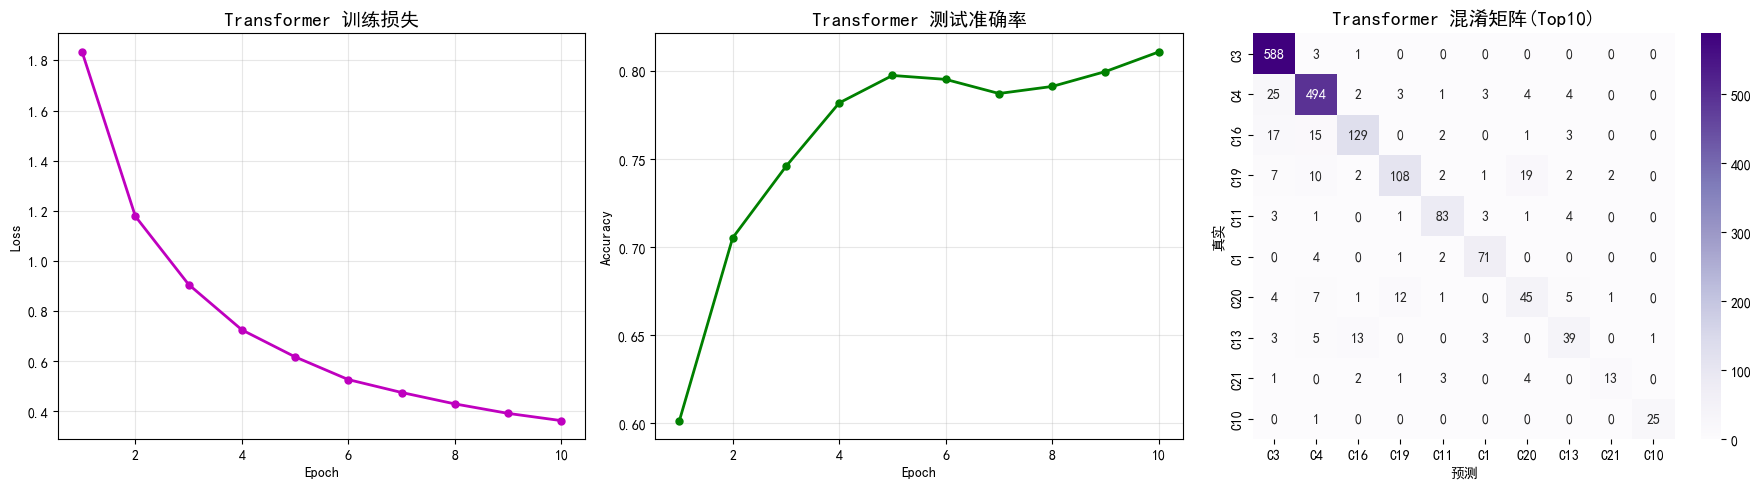

In [10]:
# ============================================================================
# 第9部分：Transformer Encoder 文本分类模型
# ============================================================================

class PositionalEncoding(nn.Module):
    """
    位置编码 (Positional Encoding)
    
    Transformer没有RNN的递归结构，无法感知token的位置顺序。
    位置编码通过正弦/余弦函数为每个位置生成唯一的编码向量，
    加到词向量上，让模型知道每个词在句子中的位置。
    
    公式:
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=500):
        super().__init__()
        # 预计算位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度用sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度用cos
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)  # 注册为buffer，不参与梯度更新
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    """
    基于Transformer Encoder的文本分类模型
    
    结构:
        Embedding → PositionalEncoding → N × TransformerEncoderLayer → 全局平均池化 → FC
    
    参数:
        vocab_size:  词表大小
        d_model:     模型维度（=词向量维度）
        nhead:       多头注意力的头数（d_model必须能被nhead整除）
        num_layers:  Transformer编码器层数
        dim_ff:      前馈网络隐藏层维度
        num_classes: 输出类别数
    """
    def __init__(self, vocab_size, d_model=EMBEDDING_DIM, nhead=NUM_HEADS,
                 num_layers=NUM_LAYERS, dim_ff=FF_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model, max_len=MAX_SEQ_LEN)
        
        # TransformerEncoderLayer: 一层Transformer编码器
        #   - 多头自注意力 (Multi-Head Self-Attention)
        #   - 前馈网络 (Feed-Forward Network)
        #   - 残差连接 + LayerNorm
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=0.1,
            batch_first=True  # 输入格式 (batch, seq, feature)
        )
        
        # 堆叠多层编码器
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, x):
        """
        数据流:
            x: (batch, seq_len)
            → Embedding: (batch, seq_len, d_model)
            → + PositionalEncoding
            → TransformerEncoder: (batch, seq_len, d_model)
            → 全局平均池化: (batch, d_model)  对seq_len维度取平均
            → FC: (batch, num_classes)
        """
        # 生成padding mask: True表示该位置是padding，需要被忽略
        # 这样注意力机制不会关注padding位置
        pad_mask = (x == PAD_IDX)  # (batch, seq_len)
        
        x = self.embedding(x)           # (batch, seq, d_model)
        x = self.pos_encoder(x)         # 加上位置编码
        x = self.dropout(x)
        
        # Transformer编码
        x = self.transformer_encoder(x, src_key_padding_mask=pad_mask)
        
        # 全局平均池化: 对序列维度取平均，得到固定长度的文本表示
        # 忽略padding位置的贡献
        mask_expanded = (~pad_mask).unsqueeze(-1).float()  # (batch, seq, 1)
        x = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        
        return self.fc(x)  # (batch, num_classes)


# --- 初始化并训练 ---
model_tf = TransformerClassifier(VOCAB_SIZE).to(DEVICE)
criterion_tf = nn.CrossEntropyLoss()
optimizer_tf = optim.Adam(model_tf.parameters(), lr=LEARNING_RATE)

print(f"Transformer 参数量: {sum(p.numel() for p in model_tf.parameters()):,}")

history_tf = train_and_evaluate_mc(model_tf, "Transformer", criterion_tf, optimizer_tf, EPOCHS)

# 最终评估
tf_acc, tf_f1m, tf_f1w, tf_preds, tf_labels = eval_model_mc(model_tf, test_loader)
tf_prec = precision_score(tf_labels, tf_preds, average='weighted', zero_division=0)
tf_rec  = recall_score(tf_labels, tf_preds, average='weighted', zero_division=0)

print(f"\n--- Transformer 最终结果 ---")
print(f"Accuracy: {tf_acc:.4f}, F1(macro): {tf_f1m:.4f}, F1(weighted): {tf_f1w:.4f}")

plot_training_and_cm(history_tf, "Transformer", tf_preds, tf_labels, 'm', 'Purples')

## 第10部分：实验结果汇总与综合对比分析

Reuters 46分类 实验结果汇总
         模型    准确率  Precision(加权)  Recall(加权)  F1(macro)  F1(weighted)
Naive Bayes 0.7640         0.7432      0.7640     0.4010        0.7320
    TextCNN 0.7725         0.7464      0.7725     0.4954        0.7439
     BiLSTM 0.3571         0.2826      0.3571     0.0374        0.2799
Transformer 0.8108         0.8017      0.8108     0.6236        0.8001

最佳模型（按F1-weighted）: Transformer


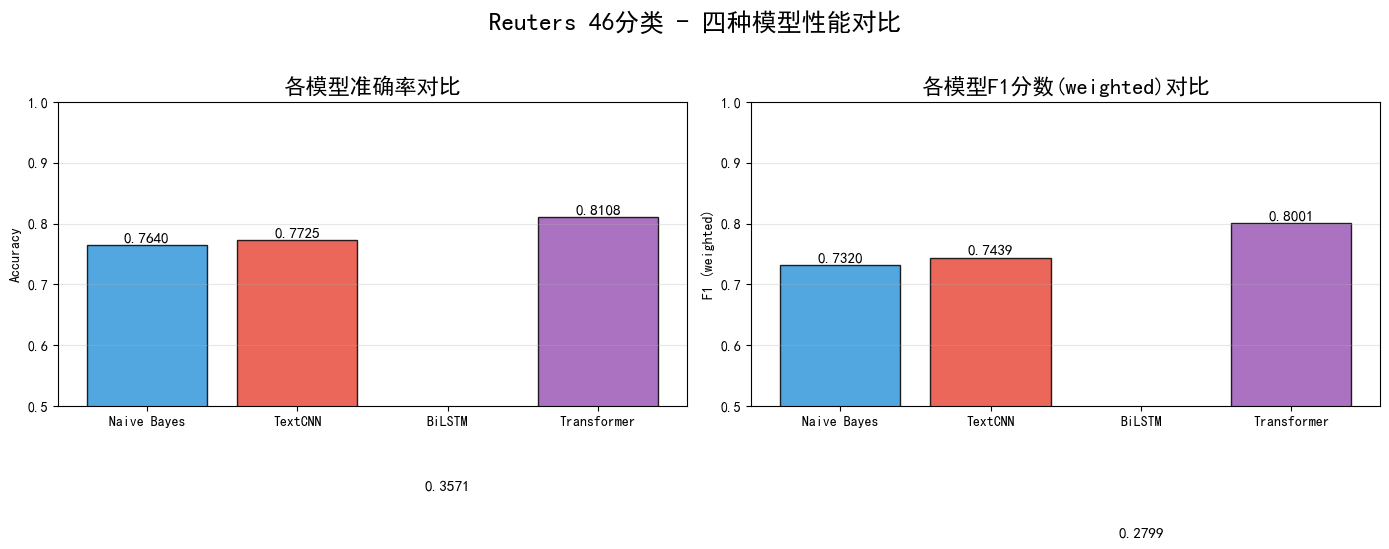

In [11]:
# ============================================================================
# 第10部分：实验结果汇总与综合对比
# ============================================================================
print("=" * 60)
print("Reuters 46分类 实验结果汇总")
print("=" * 60)

# --- 10.1 结果汇总表 ---
results_df = pd.DataFrame({
    '模型':          ['Naive Bayes', 'TextCNN', 'BiLSTM', 'Transformer'],
    '准确率':        [nb_acc, cnn_acc, lstm_acc, tf_acc],
    'Precision(加权)': [nb_prec, cnn_prec, lstm_prec, tf_prec],
    'Recall(加权)':   [nb_recall, cnn_rec, lstm_rec, tf_rec],
    'F1(macro)':     [nb_f1_macro, cnn_f1m, lstm_f1m, tf_f1m],
    'F1(weighted)':  [nb_f1_weight, cnn_f1w, lstm_f1w, tf_f1w],
})
print(results_df.to_string(index=False, float_format='%.4f'))

best_idx = results_df['F1(weighted)'].idxmax()
print(f"\n最佳模型（按F1-weighted）: {results_df.loc[best_idx, '模型']}")

# --- 10.2 柱状图对比 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
model_names = results_df['模型'].tolist()

# 准确率
bars1 = axes[0].bar(model_names, results_df['准确率'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('各模型准确率对比', fontsize=16)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, results_df['准确率']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# F1(weighted)
bars2 = axes[1].bar(model_names, results_df['F1(weighted)'], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('各模型F1分数(weighted)对比', fontsize=16)
axes[1].set_ylabel('F1 (weighted)')
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, results_df['F1(weighted)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Reuters 46分类 - 四种模型性能对比', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

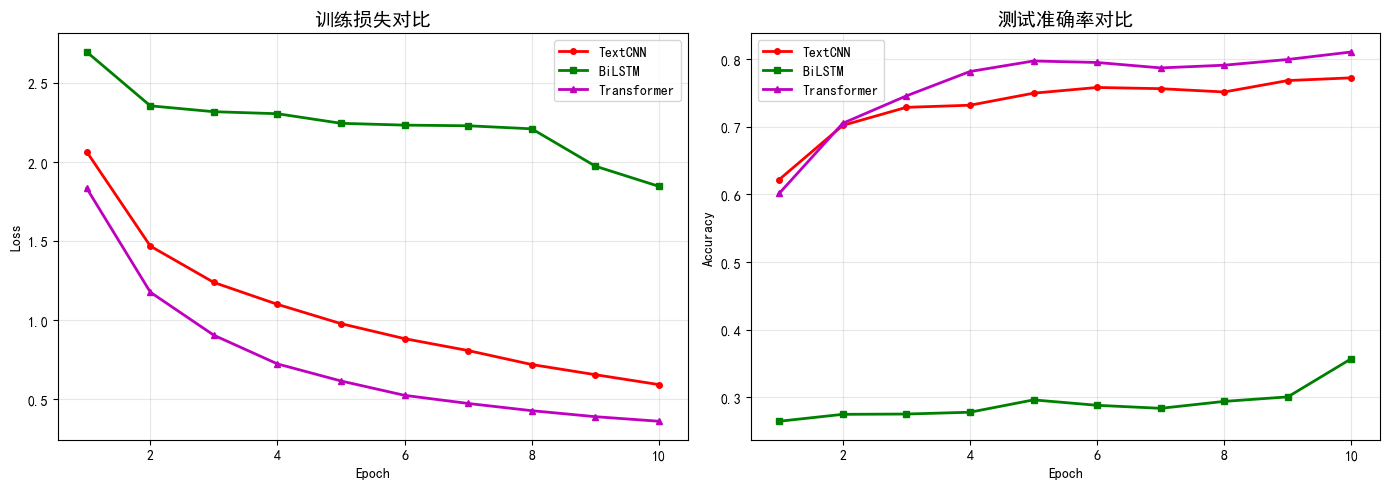

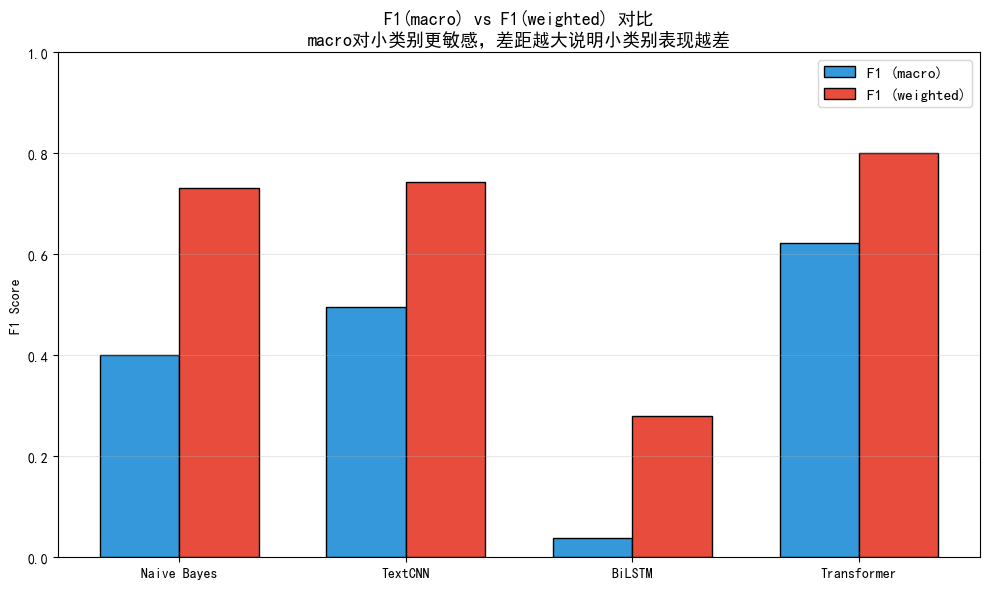

In [12]:
# --- 10.3 训练曲线对比 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, EPOCHS + 1)

# 训练损失
axes[0].plot(ep, history_cnn['train_loss'], 'r-o', linewidth=2, markersize=4, label='TextCNN')
axes[0].plot(ep, history_lstm['train_loss'], 'g-s', linewidth=2, markersize=4, label='BiLSTM')
axes[0].plot(ep, history_tf['train_loss'], 'm-^', linewidth=2, markersize=4, label='Transformer')
axes[0].set_title('训练损失对比', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 测试准确率
axes[1].plot(ep, history_cnn['test_acc'], 'r-o', linewidth=2, markersize=4, label='TextCNN')
axes[1].plot(ep, history_lstm['test_acc'], 'g-s', linewidth=2, markersize=4, label='BiLSTM')
axes[1].plot(ep, history_tf['test_acc'], 'm-^', linewidth=2, markersize=4, label='Transformer')
axes[1].set_title('测试准确率对比', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10.4 F1(macro) vs F1(weighted) 对比 ---
# macro F1 对小类别更敏感，weighted F1 反映整体表现
# 两者差距越大，说明模型在小类别上表现越差
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(model_names))
width = 0.35

bars_macro = ax.bar(x_pos - width/2, results_df['F1(macro)'], width, 
                     label='F1 (macro)', color='#3498db', edgecolor='black')
bars_weight = ax.bar(x_pos + width/2, results_df['F1(weighted)'], width,
                      label='F1 (weighted)', color='#e74c3c', edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names)
ax.set_ylabel('F1 Score')
ax.set_title('F1(macro) vs F1(weighted) 对比\nmacro对小类别更敏感，差距越大说明小类别表现越差', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('f1_macro_vs_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

## 第11部分：实验结论

### 多分类任务的特殊挑战
1. **类别不均衡**: Reuters数据集中部分类别样本极少，模型容易忽略小类别
2. **类别数量多**: 46个类别的决策边界比二分类复杂得多
3. **评价指标选择**: macro F1对小类别更公平，weighted F1反映整体表现

### 关键发现
- Transformer的自注意力机制在多分类任务中优势明显，能更好地捕捉文本的全局语义
- F1(macro)与F1(weighted)的差距反映了模型在小类别上的表现
- 传统的Naive Bayes在多分类任务中仍然是一个有竞争力的基准

In [13]:
# --- 最终结果输出 ---
print("=" * 70)
print("Reuters 46分类 最终实验结果")
print("=" * 70)
print(results_df.to_string(index=False, float_format='%.4f'))
print("=" * 70)
print("\n实验完成！所有图表已保存到当前目录。")

Reuters 46分类 最终实验结果
         模型    准确率  Precision(加权)  Recall(加权)  F1(macro)  F1(weighted)
Naive Bayes 0.7640         0.7432      0.7640     0.4010        0.7320
    TextCNN 0.7725         0.7464      0.7725     0.4954        0.7439
     BiLSTM 0.3571         0.2826      0.3571     0.0374        0.2799
Transformer 0.8108         0.8017      0.8108     0.6236        0.8001

实验完成！所有图表已保存到当前目录。
